# Phantom reconstruction comparison

This notebook reproduces the phantom reconstruction comparison figure. It compares BART NLINV/ENLIVE-style reconstructions with the proposed lifted \(\ell_{1,2}\) reconstruction for acceleration factors \(R=3,4,5\).

Before running this notebook, generate the reconstruction outputs using:

- `exp/Exp3_realdata_phantom.m` for the proposed method;
- `exp/exp2_NLINV_phantom.ipynb` for the BART NLINV baseline.

Required files:
- `output/phantom/ENLIVE_phantom.mat`
- `output/phantom/l12_recon.mat`
- `data/phantom/pat.mat`

In [ ]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from PIL import Image

def disp(im,clip = False,figsize=(4,4)): # to avoid code repetition
    pixvals = abs(np.squeeze(im))
    if clip == True:
        minval = np.percentile(pixvals, 0.05) #some values are close to zero, clip it out for higher contrast
        maxval = np.percentile(pixvals, 99.95)
    else:
        minval = np.percentile(pixvals, 0) #some values are close to zero, clip it out for higher contrast
        maxval = np.percentile(pixvals, 100)
    pixvals = np.clip(pixvals, minval, maxval)
    pixvals = ((pixvals - minval) / (maxval - minval)) * 255
    img = Image.fromarray(pixvals.astype(np.uint8))
    return img

In [28]:
images = []
diff = []

Load the baseline results

In [ ]:
from scipy.io import loadmat
ENLIVE = loadmat('../output/phantom/ENLIVE_phantom.mat')

In [ ]:
ENLIVE.keys()

dict_keys(['__header__', '__version__', '__globals__', 'phantom_3', 'phantom_4', 'phantom_5', 'phantom_10', 'phantom_15', 'phantom_20'])

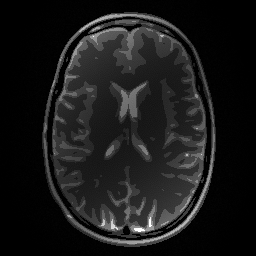

In [ ]:
ENLIVE3 = np.fft.fftshift(np.squeeze(ENLIVE['phantom_3']))
images.append(disp(ENLIVE,True))
disp(ENLIVE,True)

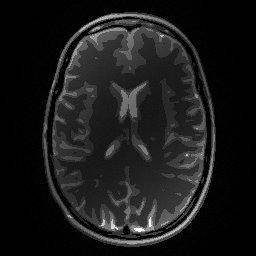

In [ ]:
ENLIVE4 = np.fft.fftshift(np.squeeze(ENLIVE['phantom_4']))
images.append(disp(ENLIVE4,True))
disp(ENLIVE4,True)

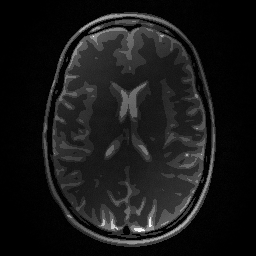

In [ ]:
ENLIVE5 = np.fft.fftshift(np.squeeze(ENLIVE['phantom_5']))
images.append(disp(ENLIVE5,False))
disp(ENLIVE5,False)

Load the $l_{1,2}$ results

In [ ]:
my_recon = loadmat('../output/phantom/l12_recon.mat',struct_as_record=False, squeeze_me=True)
my_recon = my_recon['Rec_l12']
truth = my_recon.Out_best_pat_3.org_im
my_recon_3  = my_recon.Out_best_pat_3.recon_im.im
my_recon_4  = my_recon.Out_best_pat_4.recon_im.im
my_recon_5  = my_recon.Out_best_pat_5.recon_im.im


In [ ]:
scale = np.vdot(ENLIVE3[:],truth[:])/np.vdot(ENLIVE3[:],ENLIVE3[:])
#images.append(disp(ENLIVE3*scale -truth,False))
disp(ENLIVE3*scale -truth,False)
diff.append(np.linalg.norm(ENLIVE3*scale -truth,'fro')/np.linalg.norm(truth,'fro'))

In [ ]:
scale = np.vdot(ENLIVE4[:],truth[:])/np.vdot(ENLIVE4[:],ENLIVE4[:])
#images.append(disp(ENLIVE4*scale -truth,False))
disp(ENLIVE4*scale -truth,False)
diff.append(np.linalg.norm(ENLIVE4*scale -truth,'fro')/np.linalg.norm(truth,'fro'))

In [ ]:
scale = np.vdot(ENLIVE5[:],truth[:])/np.vdot(ENLIVE5[:],ENLIVE5[:])
#images.append(disp(ENLIVE5*scale -truth,False))
disp(ENLIVE5*scale -truth,False)
diff.append(np.linalg.norm(ENLIVE5*scale -truth,'fro')/np.linalg.norm(truth,'fro'))

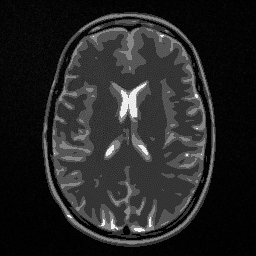

In [32]:
images.append(disp(my_recon_3,False))
disp(my_recon_3,False)

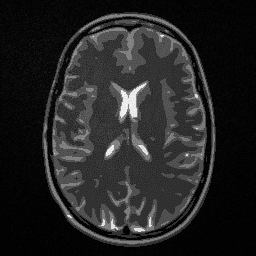

In [33]:
images.append(disp(my_recon_4,False))
disp(my_recon_4,False)

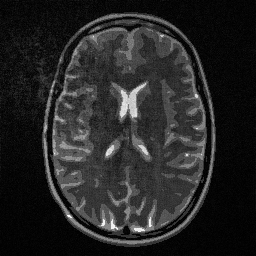

In [34]:
images.append(disp(my_recon_5,False))
disp(my_recon_5,False)

In [ ]:
#check if there is a global scaling factor that can be applied to my recon to minimize the error
scale = np.vdot(my_recon_3[:],truth[:])/np.vdot(my_recon_3[:],my_recon_3[:])
#images.append(disp(my_recon_3*scale -truth,False))
disp(my_recon_3*scale -truth,False)
diff.append(np.linalg.norm(my_recon_3*scale -truth,'fro')/np.linalg.norm(truth,'fro'))

In [43]:
scale = np.vdot(my_recon_4[:],truth[:])/np.vdot(my_recon_4[:],my_recon_4[:])
#images.append(disp(my_recon_4*scale -truth,False))
disp(my_recon_4*scale -truth,False)
diff.append(np.linalg.norm(my_recon_4*scale -truth,'fro')/np.linalg.norm(truth,'fro'))

In [44]:
scale = np.vdot(my_recon_5[:],truth[:])/np.vdot(my_recon_5[:],my_recon_5[:])
#images.append(disp(my_recon_5*scale -truth,False))
disp(my_recon_5*scale -truth,False)
diff.append(np.linalg.norm(my_recon_5*scale -truth,'fro')/np.linalg.norm(truth,'fro'))

Load the sampling pattern

In [ ]:
pat = loadmat('../data/phantom/pat.mat')
pat_3 = pat['pat_3']
pat_4 = pat['pat_4']
pat_5 = pat['pat_5']

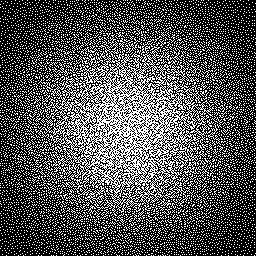

In [35]:
images.append(disp(pat_3))
disp(pat_3)

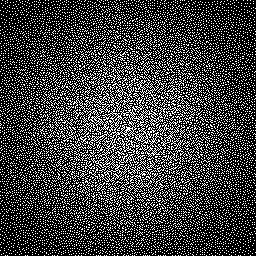

In [36]:
images.append(disp(pat_4))
disp(pat_4)

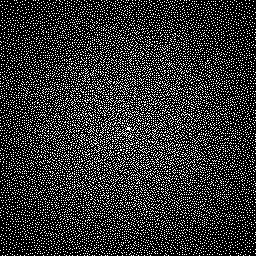

In [37]:
images.append(disp(pat_5))
disp(pat_5)

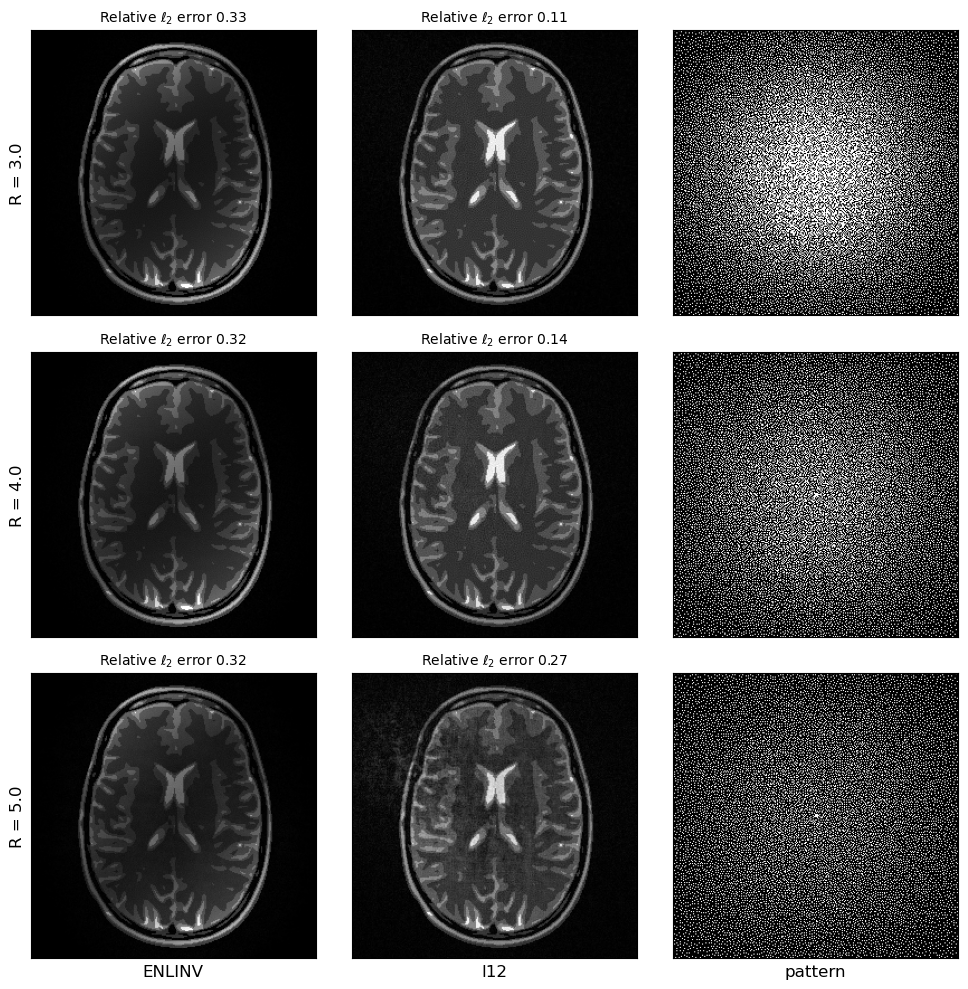

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

# Labels for the axes
x_labels = [ 'ENLIVE','l12', 'pattern']
y_labels = ['R = 3.0', 'R = 4.0', 'R = 5.0']

# Plot each array in the grid
for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        ax.imshow(images[i + 3*j], cmap='gray')  # Adjust cmap as needed
        ax.set_xticks([])  # Hide x ticks but keep labels
        ax.set_yticks([])  # Hide y ticks but keep labels
        if j == 0 or j == 1:
            error_index = i + (3 * j)  # Calculate index for ell2_errors
            ax.set_title(f'Relative $\ell_2$ error {diff[error_index]:.2f}', fontsize=10)
    
# Set x-axis labels for the bottom row
for ax, label in zip(axes[-1], x_labels):
    ax.set_xlabel(label, fontsize=12)

# Set y-axis labels for the leftmost column
for ax, label in zip(axes[:, 0], y_labels):
    ax.set_ylabel(label, fontsize=12, rotation=90)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig('high_res_plot.png', dpi=300, bbox_inches='tight')
plt.show()